## Task 2 - Data Parser Implementation (10 P):

Use the provided framework that you have now in your project. Write a reader to read in the data files and the appropriate data structures that you need in the beginning. You may only need to store things in your data structure that you will need later (e.g., lots of attributes in the reddit dump are useless for us).

Follow the instructions in the following code snippets.

In [3]:
# import the necessary library functions we prepared
from utils import create_word_cloud

In [4]:
import wordcloud
from xml.etree import ElementTree as ET
import json
import csv
import pandas as pd
import re

In [5]:
#
# Part 1
#
#  - Read all the files in the data directory (and subdirectories)
#
# You may use any available library here, but please add it to the requirements.txt and SUBMIT the changed file
# Create python classes to represent your data. For the beginning, the simple text body should be sufficient.
# However, if you want to add other metadata you are free to do so.
# Regard each folder as one dataset. So bin Part 3, you should generate three individual word clouds.
# 
# Hint: You do _not_ need to represent the thread structure of the reddit data with your Python class instances.
# 
# Example:
#loremipsum = read_lorem_ipsum_text()
    
# TODO - ADD YOUR OTHER READER HERE


from importlib.resources import path
import glob

file_path_x = glob.glob(f"data/debates/*.xml")
file_path_j = "data/reddit/redditdump.json"
file_path_c = glob.glob(f"data/tv/*.csv")

def xml_parsing ():
        data = ""
        for file_path in file_path_x:
                f = open(file_path, 'r', encoding='utf-8')
                tree = ET.parse(f)
                root = tree.getroot()
                value = root.findall('topic/utterance')
                texte = []
                for element in value:
                        texte.append(element.text)
                        data = " ".join(texte)
        return data
         

def json_parsing():
        texte_json = []
        with open(file_path_j, "r", encoding='utf-8') as f:
                data = json.load(f)

        for item in data:
                children = item.get('data', {}).get('children', {})
                for child in children:
                        kind = child.get('kind')
                        child_data = child.get('data',{})
                        if kind == 't3':
                                text = child_data.get('selftext')
                                if text:
                                        texte_json.append(text)
                                 
                        elif kind == 't1':
                                content = child_data.get('body')
                                if content:
                                        texte_json.append(content)
        all = " ".join(texte_json)
        redu_first = re.sub(r'https?:[^\s]+', '' , all)
        redu_second = re.sub(r'\n', '', redu_first)
        redu_third = re.sub(r'[**]', '', redu_second)
        final = re.sub(r'\\', '', redu_third)
        return final


def csv_parsing():
        transcript = ""
        for file_path in file_path_c:
                f = open(file_path, "r", encoding='utf-8')
                df = pd.read_csv(f, usecols=["transcript"])
                transcript += " ".join(df["transcript"].dropna())
        return transcript

In [6]:
json_parsing()

'The first Presidential Debate for the 2016 Elections will air tonight at 9:00PM Eastern at Hofstra University in New York. The debate will feature Donald Trump and Hillary Clinton in their first head-to-head televised debate. The debate will be 90 minutes and commercial free.The Debate is hosted by the Commission on Presidential Debates and will be moderated by NBC’s Lester Holt. Hillary Clinton will [receive the first question](-----Where to Watch-Unlike the primaries, these debates are hosted by the Commission on Presidential Debates and the broadcast is not restricted to one network, making for a wide range of viewing options. Here are just a few of the ways you can watch:Television:The event will be broadcast on most major TV channels, including ABC, CBS, CNN, C-SPAN, Fox News, MSNBC, and Univision.Live Streams:[C-SPAN]([Washington Post (YouTube)]([PBS (YouTube)]([NBC (YouTube)]([Bloomberg Politics (Twitter with real-time fact checking)]([ABC (Facebook)](------Live Discussion-If y

In [7]:
csv_parsing()

'>> NO, I DIDN\'T SAY THAT AT ALL. I DON\'T THINK YOU UNDERSTOOD WHAT WAS SAID. THIS WAS LOCKER ROOM TALK. I\'M NOT PROUD OF IT. I APOLOGIZED TO MY FAMILY, I THAT? >> FRANKLY, YOU HEAR THESE THINGS. THEY ARE SAID. I WAS EMBARRASSED BY IT. ON POLITICS, POLICIES, PRINCIPLE, BUT I NEVER WHAT HE DOES TO WOMEN. AND HE HAS SAID THAT THE VIDEO DOESN\'T REPRESENT WHO HE IS. BUT I THINK IT\'S CLEAR TO ANYONE WHO HEARD IT THAT IT REPRESENTS EXACTLY WHO HE IS. >> MR. FRUMP -- I WANT TO GET TO AUDIENCE QUESTIONS ONLINE QUESTIONS. >> SO, SHE\'S ALLOWED TO DO THAT HAPPENED. IF YOU LOOK AT BILL CLINTON, FAR WORSE, MINOR WORDS AND HIS WAS ACTION. HIS WAS WHAT HE\'S DONE TO WOMEN, COUNTRY. THAT\'S HIS CHOICE. WHEN I HEAR SOMETHING LIKE THAT, I AM REMINDED OF WHAT MY FRIEND, COUNTRY. THAT\'S HIS CHOICE. WHEN I HEAR SOMETHING LIKE THAT, I AM REMINDED OF WHAT MY FRIEND, I WAS SO SURPRISED SEE HIM SIGN ON WITH THE DEVIL. BUT WHEN YOU TALK ABOUT APOLOGY, I THINK THE ONE THAT SHOULD YOU REALLY BE APOLOGIZING

In [8]:
xml_data = xml_parsing()
json_data = json_parsing()
csv_data = csv_parsing()


In [9]:
# 
# Part 2
#
#  - Count the words in a map. Do so for each dataset.
#
# Example:
#word_count_lorem = {}
#words = loremipsum.split(" ")
#for word in words:
    #word_count_lorem[word] = word_count_lorem.get(word, 0) + 1

# TODO - ADD YOUR OTHER COUNTER FUNCTIONS HERE

word_count_xml = {}
words = xml_data.split()

for word in words:
        word_count_xml[word] = word_count_xml.get(word, 0) + 1

print(word_count_xml)



{'Good': 3, 'evening': 2, 'from': 41, 'Hofstra': 3, 'University': 5, 'in': 219, 'Hempstead,': 1, 'New': 15, 'York.': 2, 'I': 434, 'am': 47, 'Lester': 2, 'Holt,': 1, 'anchor': 1, 'of': 338, '"NBC': 1, 'Nightly': 1, 'News.”': 1, 'want': 48, 'to': 571, 'welcome': 2, 'you': 258, 'the': 596, 'first': 17, 'presidential': 7, 'debate.': 3, 'The': 46, 'participants': 1, 'tonight': 2, 'are': 217, 'Donald': 23, 'Trump': 7, 'and': 315, 'Hillary': 9, 'Clinton.': 6, 'This': 6, 'debate': 7, 'is': 285, 'sponsored': 1, 'by': 50, 'Commission': 1, 'on': 90, 'Presidential': 1, 'Debates,': 1, 'a': 316, 'nonpartisan,': 1, 'nonprofit': 1, 'organization.': 1, 'commission': 2, 'drafted': 1, "tonight's": 1, 'format,': 1, 'rules': 1, 'have': 252, 'been': 56, 'agreed': 2, 'campaigns.': 2, '90-minute': 1, 'divided': 1, 'into': 31, 'six': 3, 'segments,': 1, 'each': 4, '15': 4, 'minutes': 10, 'long.': 2, "We'll": 3, 'explore': 1, 'three': 2, 'topic': 1, 'areas': 1, 'tonight:': 1, 'Achieving': 1, 'prosperity;': 1, "A

In [10]:
word_count_json = {}
words_j = json_data.split()

for word in words_j:
        word_count_json[word] = word_count_json.get(word, 0) + 1

print(word_count_json)


{'The': 5, 'first': 5, 'Presidential': 4, 'Debate': 4, 'for': 23, 'the': 100, '2016': 1, 'Elections': 1, 'will': 27, 'air': 1, 'tonight': 3, 'at': 11, '9:00PM': 1, 'Eastern': 1, 'Hofstra': 1, 'University': 1, 'in': 31, 'New': 1, 'York.': 1, 'debate': 10, 'feature': 1, 'Donald': 7, 'Trump': 23, 'and': 56, 'Hillary': 9, 'Clinton': 8, 'their': 5, 'head-to-head': 1, 'televised': 1, 'debate.': 4, 'be': 20, '90': 2, 'minutes': 2, 'commercial': 1, 'free.The': 1, 'is': 29, 'hosted': 2, 'by': 9, 'Commission': 2, 'on': 19, 'Debates': 2, 'moderated': 1, 'NBC’s': 1, 'Lester': 1, 'Holt.': 1, '[receive': 1, 'question](-----Where': 1, 'to': 63, 'Watch-Unlike': 1, 'primaries,': 1, 'these': 2, 'debates': 3, 'are': 16, 'broadcast': 2, 'not': 18, 'restricted': 1, 'one': 4, 'network,': 1, 'making': 2, 'a': 49, 'wide': 1, 'range': 1, 'of': 32, 'viewing': 1, 'options.': 1, 'Here': 1, 'just': 12, 'few': 2, 'ways': 1, 'you': 11, 'can': 2, 'watch:Television:The': 1, 'event': 2, 'most': 2, 'major': 1, 'TV': 1, 

In [12]:


word_count_csv = {}
final = re.sub(r'>>', '', csv_data)

words_c = final.split(" ")

for word in words_c:
        word_count_csv[word] = word_count_csv.get(word, 0) + 1

print (word_count_csv)

{'': 7343, 'NO,': 539, 'I': 9690, "DIDN'T": 465, 'SAY': 913, 'THAT': 5457, 'AT': 1261, 'ALL.': 202, "DON'T": 993, 'THINK': 1382, 'YOU': 7102, 'UNDERSTOOD': 221, 'WHAT': 2290, 'WAS': 3396, 'SAID.': 421, 'THIS': 2206, 'LOCKER': 322, 'ROOM': 327, 'TALK.': 302, "I'M": 675, 'NOT': 1715, 'PROUD': 279, 'OF': 4977, 'IT.': 1423, 'APOLOGIZED': 127, 'TO': 9362, 'MY': 1560, 'FAMILY,': 133, 'THAT?': 380, 'FRANKLY,': 98, 'HEAR': 308, 'THESE': 305, 'THINGS.': 231, 'THEY': 1220, 'ARE': 1205, 'EMBARRASSED': 179, 'BY': 1005, 'ON': 1442, 'POLITICS,': 30, 'POLICIES,': 30, 'PRINCIPLE,': 30, 'BUT': 2095, 'NEVER': 531, 'HE': 3279, 'DOES': 454, 'WOMEN.': 877, 'AND': 6693, 'HAS': 1843, 'SAID': 1498, 'THE': 9502, 'VIDEO': 202, "DOESN'T": 827, 'REPRESENT': 230, 'WHO': 1035, 'IS.': 384, "IT'S": 1012, 'CLEAR': 55, 'ANYONE': 52, 'HEARD': 332, 'IT': 2872, 'REPRESENTS': 13, 'EXACTLY': 19, 'MR.': 586, 'FRUMP': 10, '--': 3451, 'WANT': 1148, 'GET': 724, 'AUDIENCE': 114, 'QUESTIONS': 66, 'ONLINE': 6, 'QUESTIONS.': 34, 'S

In [ ]:
# 
# Part 3
#
#  - Create a word cloud for the dataset.
# 
# Example:


# TODO - CREATE THE OTHER THREE WORDCLOUDS HERE

### Wordcloud 1: Debates (xml)

Word Cloud for XML:


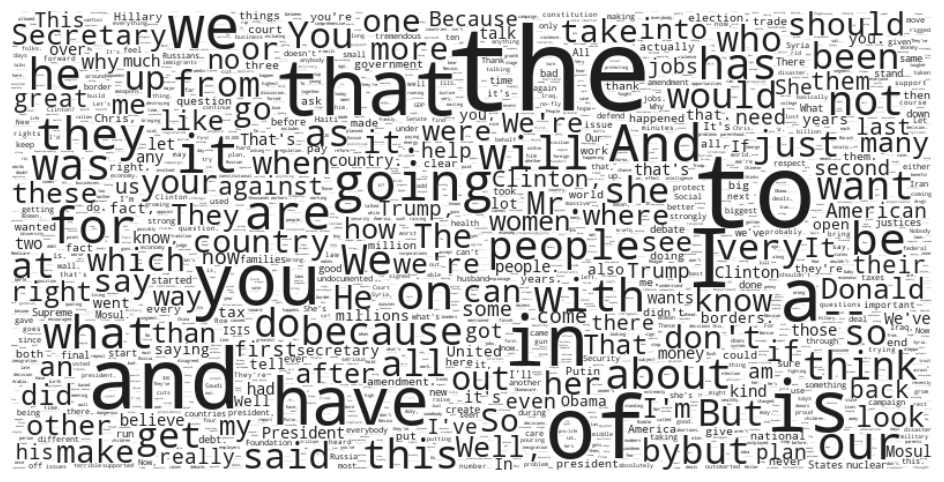

In [ ]:
create_word_cloud(word_count_xml, "Word Cloud for XML")

### Wordcloud 2: Reddit (json)

Word Cloud for JSON:


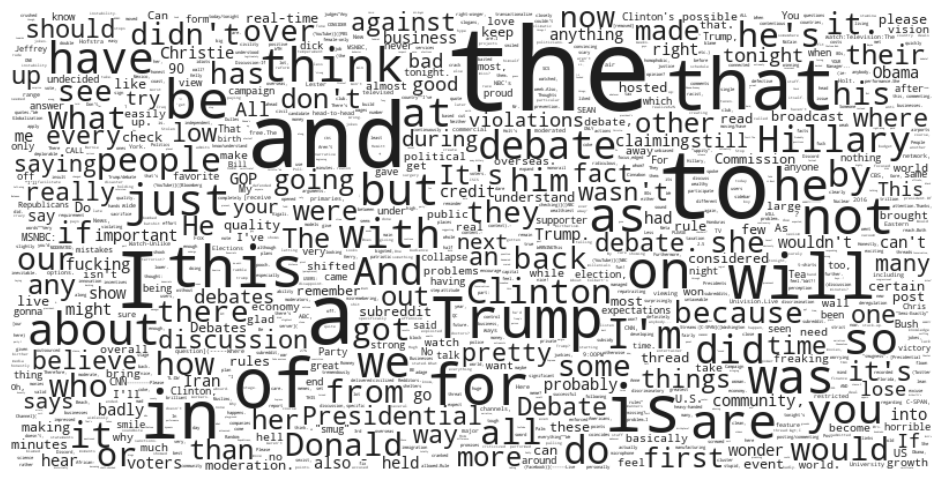

In [ ]:
create_word_cloud(word_count_json, "Word Cloud for JSON")

### Wordcloud 3: TV (csv)

Word Cloud for CSV:


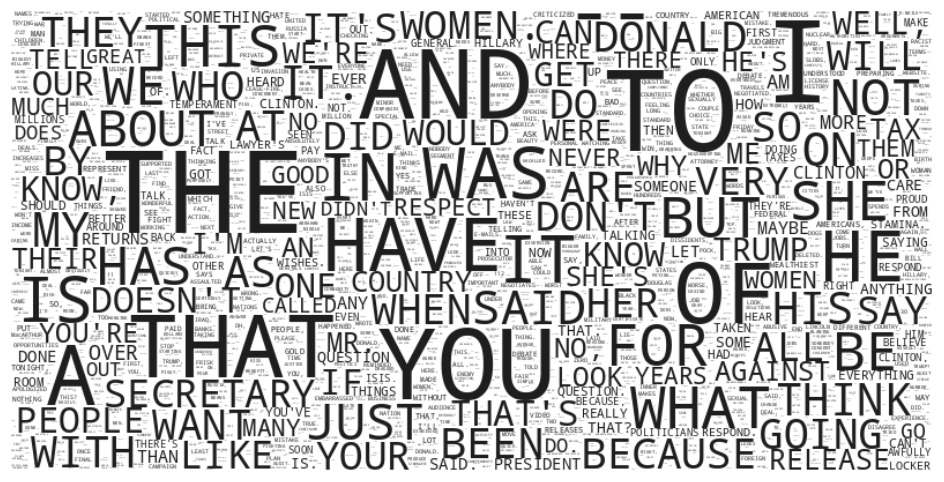

In [13]:
create_word_cloud(word_count_csv, "Word Cloud for CSV")